In [2]:
import pandas as pd
import numpy as np

# 1. Configuração de tempo (1 semana, minuto a minuto)
tempo = pd.date_range(start='2026-04-20', end='2026-04-27', freq='min')
n = len(tempo)

# 2. Criando o Ciclo Diurno (Baseado em Senoide)
# Hora do dia em radianos para oscilação
hora_rad = (tempo.hour * 60 + tempo.minute) * (2 * np.pi / 1440)

# 3. Simulação das Temperaturas (°C)
# Telha: Resposta rápida, atinge 55°C fácil no sol de Manaus
temp_telha = 26 + 25 * np.sin(hora_rad - np.pi/2) + np.random.normal(0, 0.5, n)

# Grama: Resfriamento por evapotranspiração, máxima menor (~34°C) e atraso (lag)
temp_grama = 25 + 9 * np.sin(hora_rad - np.pi/1.8) + np.random.normal(0, 0.3, n)

# Amendoim: Similar à grama, mas com dossel diferente
temp_amendoim = 25 + 7 * np.sin(hora_rad - np.pi/1.7) + np.random.normal(0, 0.3, n)

# 4. Simulação de Umidade Relativa (%) - Inversamente proporcional à temperatura
ur_grama = 95 - 40 * ((temp_grama - 25) / 10) + np.random.normal(0, 1, n)
ur_grama = np.clip(ur_grama, 40, 100) # Garante que não passe de 100%

# 5. Simulação de Vazão (L/min) - Picos aleatórios simulando chuva
vazao = np.random.exponential(0.1, n)
vazao[vazao < 0.8] = 0 # Maioria do tempo sem escoamento
vazao[1000:1030] = 5 + np.random.normal(0, 1, 30) # Simula uma chuva forte

# Criar DataFrame
df_teste = pd.DataFrame({
    'Data_Hora': tempo,
    'temp_telha': temp_telha,
    'temp_grama': temp_grama,
    'temp_amendoim': temp_amendoim,
    'ur_grama': ur_grama,
    'vazao': vazao
})

# Salvar
df_teste.to_csv('dados_meteorologia_teste.csv', index=False, sep=';', decimal=',')
print("Base de dados de teste criada com sucesso!")

Base de dados de teste criada com sucesso!


Colunas encontradas: ['Data_Hora', 'temp_telha', 'temp_grama', 'temp_amendoim', 'ur_grama', 'vazao']


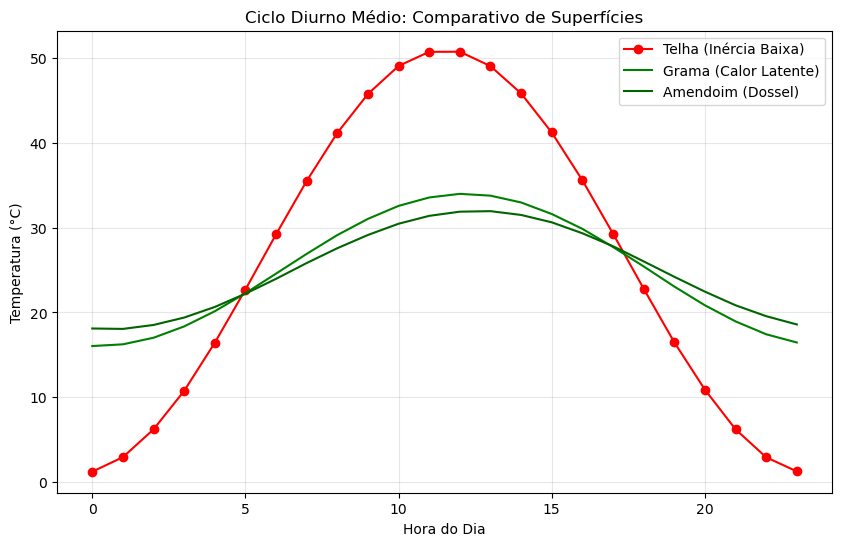

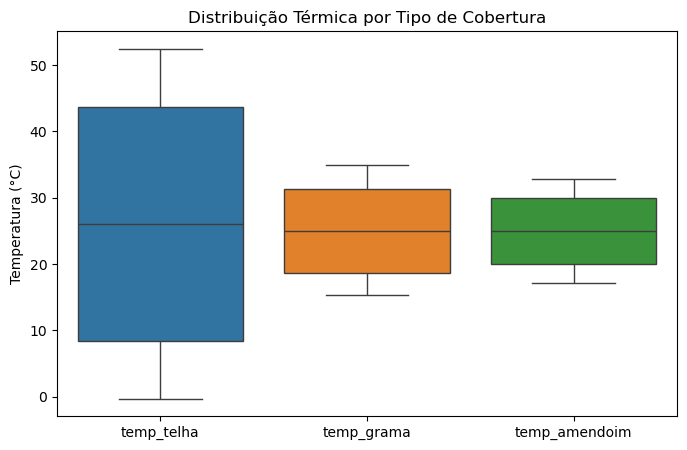

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados especificando o separador
# Se o seu ficheiro CSV tem vírgulas, usamos sep=','
# Se você alterou para ponto e vírgula no Excel, use sep=';'
# ✅ Correto
df = pd.read_csv('dados_meteorologia_teste.csv', sep=';', decimal=',')

# Vamos verificar o nome das colunas que o Python leu para ter certeza
print("Colunas encontradas:", df.columns.tolist())

# Agora o código deve funcionar
df['Data_Hora'] = pd.to_datetime(df['Data_Hora'])
df.set_index('Data_Hora', inplace=True)

# Extract hour from index and group by hour to get average daily cycle
dia_medio = df.groupby(df.index.hour).mean()

plt.figure(figsize=(10, 6))
plt.plot(dia_medio.index, dia_medio['temp_telha'], label='Telha (Inércia Baixa)', color='red', marker='o')
plt.plot(dia_medio.index, dia_medio['temp_grama'], label='Grama (Calor Latente)', color='green')
plt.plot(dia_medio.index, dia_medio['temp_amendoim'], label='Amendoim (Dossel)', color='darkgreen')

plt.title('Ciclo Diurno Médio: Comparativo de Superfícies')
plt.xlabel('Hora do Dia')
plt.ylabel('Temperatura (°C)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3. Boxplot para Análise Estatística
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['temp_telha', 'temp_grama', 'temp_amendoim']])
plt.title('Distribuição Térmica por Tipo de Cobertura')
plt.ylabel('Temperatura (°C)')
plt.show()

ESTATÍSTICAS GERAIS
       temp_telha  temp_grama  temp_amendoim  ur_grama     vazao
count    10081.00    10081.00       10081.00  10081.00  10081.00
mean        26.00       25.00          25.00     85.94      0.01
std         17.69        6.37           4.95     15.95      0.28
min         -0.31       15.24          17.06     54.04      0.00
25%          8.34       18.66          20.05     69.67      0.00
50%         26.04       25.01          25.03     95.03      0.00
75%         43.62       31.35          29.94    100.00      0.00
max         52.46       34.86          32.74    100.00      7.37

BALANÇO HÍDRICO — EVENTO DE CHUVA
Escoamento total acumulado : 149.28 L
Pico de vazão              : 7.37 L/min
Minutos com escoamento > 0 : 31 min

BALANÇO DE ENERGIA — ILHA DE CALOR
ΔT médio (telha−veg)  : 1.00 °C
ΔT máximo             : 19.96 °C
Hora do pico médio    : 11h
Painel salvo como 'painel_meteorologia.png'!


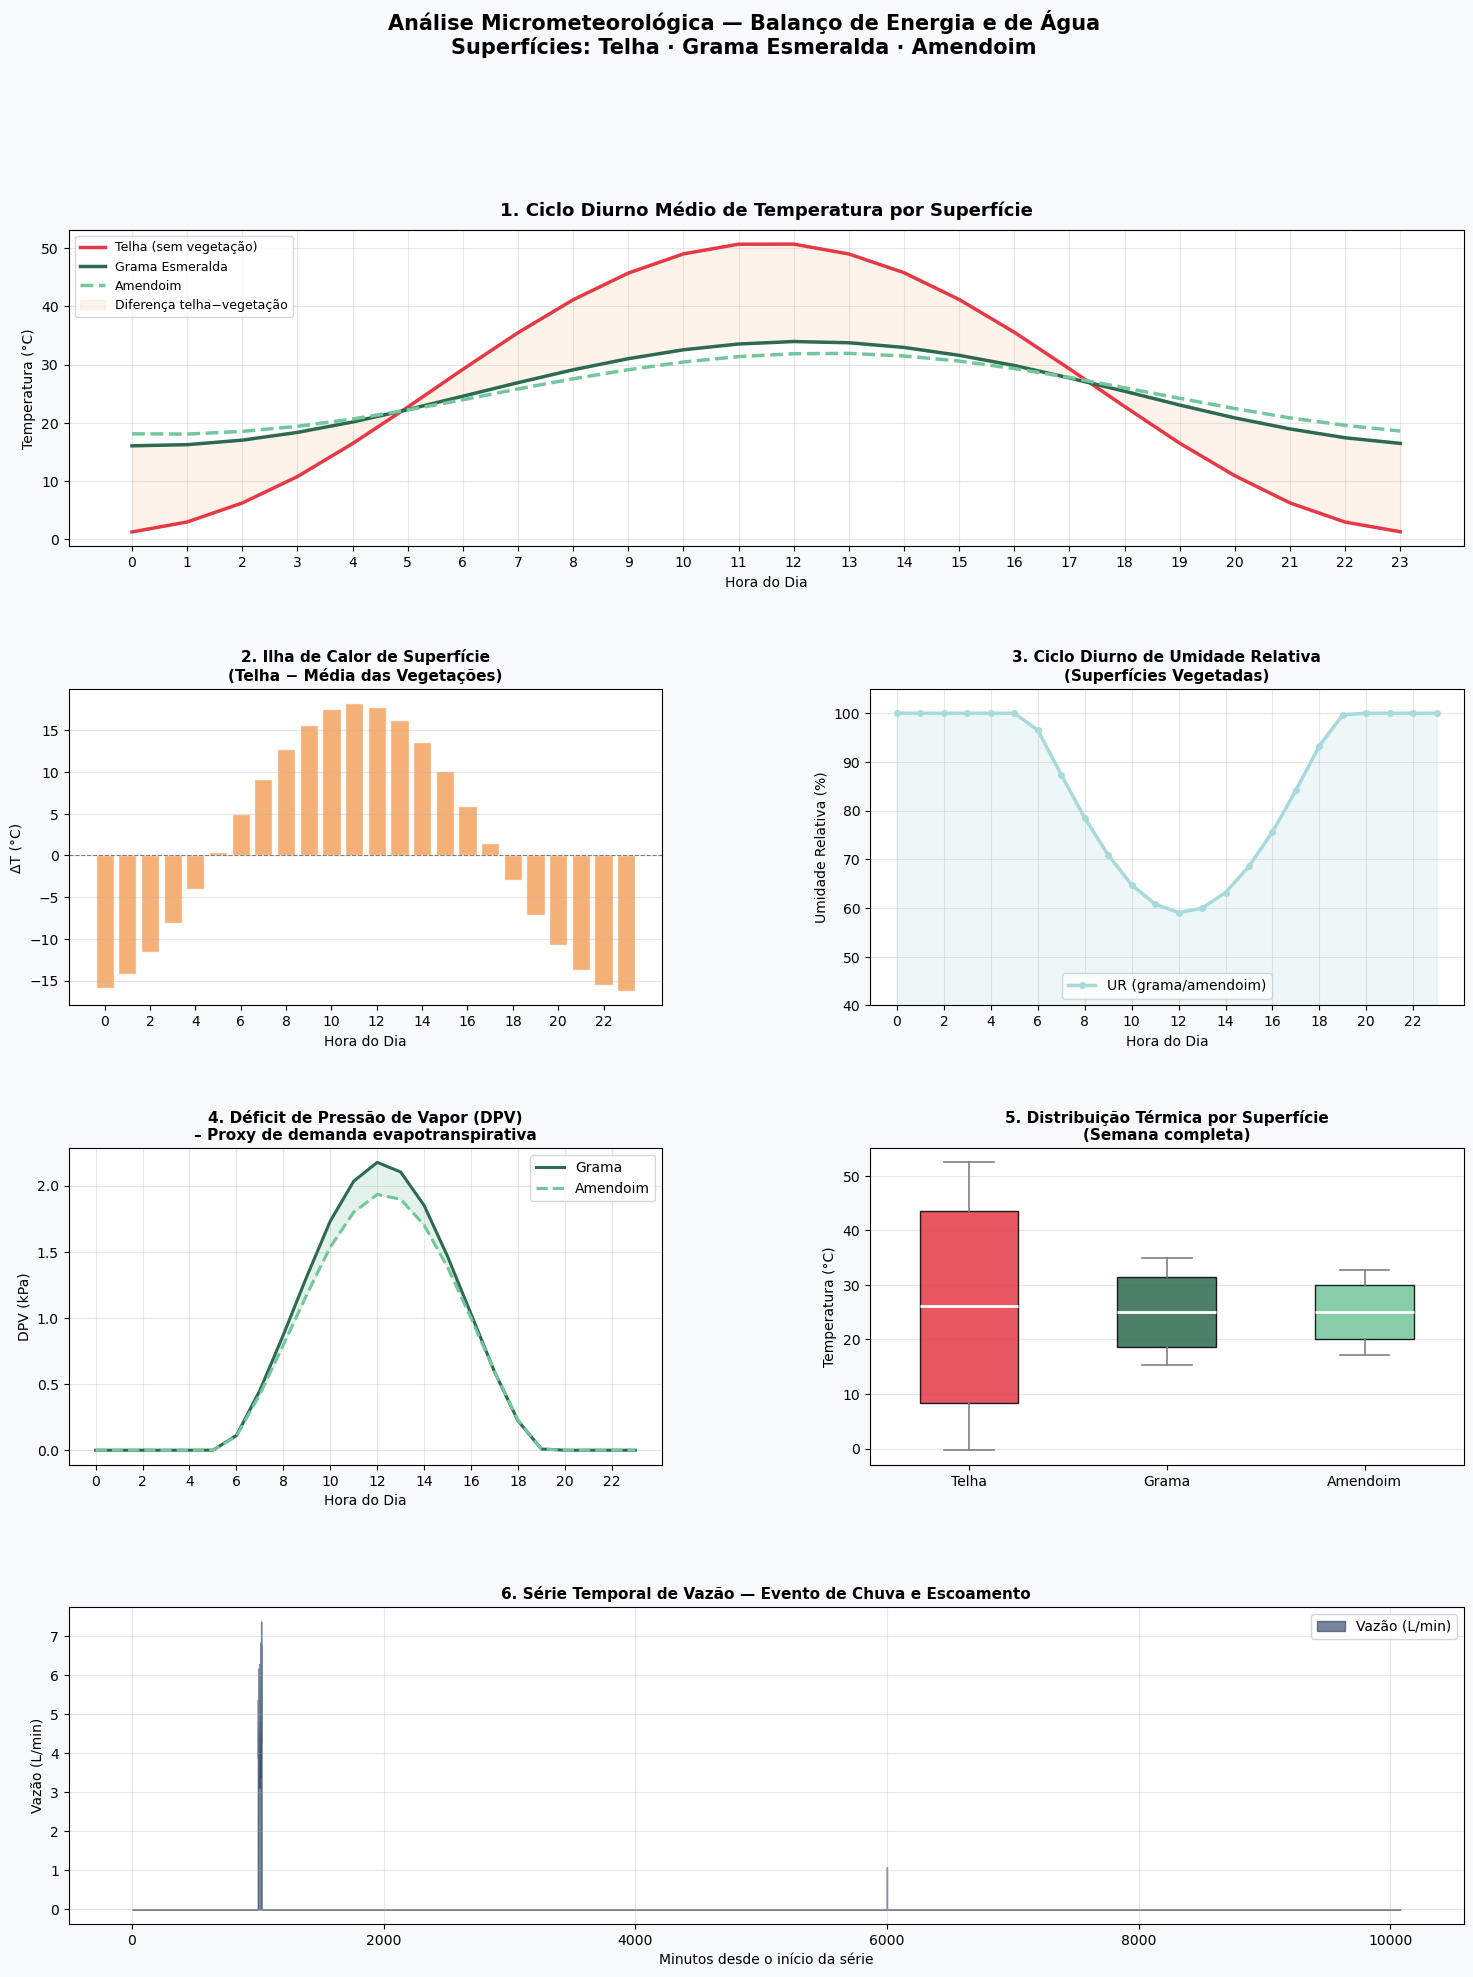

In [9]:
"""
Análise Micrometeorológica — Balanço de Energia e de Água
Superfícies: Telha · Grama Esmeralda · Amendoim

Adaptado para os dados reais da mini station.
Substitua 'dados_meteorologia_teste.csv' pelo seu arquivo real na sexta.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ══════════════════════════════════════════════════════════════════════
# 1. CARREGAR E PREPARAR OS DADOS
# ══════════════════════════════════════════════════════════════════════
df = pd.read_csv('dados_meteorologia_teste.csv', sep=';', decimal=',')
df['Data_Hora'] = pd.to_datetime(df['Data_Hora'])
df.set_index('Data_Hora', inplace=True)

# ══════════════════════════════════════════════════════════════════════
# 2. FEATURES DERIVADAS
# ══════════════════════════════════════════════════════════════════════

# --- Déficit de Pressão de Vapor (DPV) ---
# Mede a "sede" da atmosfera por vapor d'água — quanto maior, maior a
# demanda evapotranspirativa da vegetação (componente LE do balanço de energia)
# Fórmula de Magnus: pressão de saturação em kPa
def pressao_saturacao(T):
    return 0.6108 * np.exp(17.27 * T / (T + 237.3))

df['dpv_grama']    = pressao_saturacao(df['temp_grama'])    * (1 - df['ur_grama'] / 100)
df['dpv_amendoim'] = pressao_saturacao(df['temp_amendoim']) * (1 - df['ur_grama'] / 100)

# --- Ilha de Calor de Superfície ---
# Diferença entre a superfície impermeável (telha) e a média das vegetações
# É a assinatura observável do balanço de energia: mais H na telha, mais LE na vegetação
df['ilha_calor'] = df['temp_telha'] - (df['temp_grama'] + df['temp_amendoim']) / 2

# --- Ciclo diurno médio (agrupa por hora) ---
dia_medio = df.groupby(df.index.hour).mean(numeric_only=True)

# ══════════════════════════════════════════════════════════════════════
# 3. ESTATÍSTICAS DE BALANÇO HÍDRICO
# ══════════════════════════════════════════════════════════════════════
print("=" * 55)
print("ESTATÍSTICAS GERAIS")
print("=" * 55)
print(df[['temp_telha', 'temp_grama', 'temp_amendoim', 'ur_grama', 'vazao']].describe().round(2))

print("\n" + "=" * 55)
print("BALANÇO HÍDRICO — EVENTO DE CHUVA")
print("=" * 55)
# Precipitação total estimada pelo sensor (L/min integrado)
total_vazao = df['vazao'].sum()
max_vazao   = df['vazao'].max()
print(f"Escoamento total acumulado : {total_vazao:.2f} L")
print(f"Pico de vazão              : {max_vazao:.2f} L/min")
print(f"Minutos com escoamento > 0 : {(df['vazao'] > 0).sum()} min")

print("\n" + "=" * 55)
print("BALANÇO DE ENERGIA — ILHA DE CALOR")
print("=" * 55)
print(f"ΔT médio (telha−veg)  : {df['ilha_calor'].mean():.2f} °C")
print(f"ΔT máximo             : {df['ilha_calor'].max():.2f} °C")
print(f"Hora do pico médio    : {dia_medio['ilha_calor'].idxmax()}h")

# ══════════════════════════════════════════════════════════════════════
# 4. FIGURAS
# ══════════════════════════════════════════════════════════════════════
CORES = {
    'telha':    '#E63946',
    'grama':    '#2D6A4F',
    'amendoim': '#74C69D',
    'ilha':     '#F4A261',
    'dpv':      '#457B9D',
    'vazao':    '#1D3557',
    'ur':       '#A8DADC',
}

horas = dia_medio.index

fig = plt.figure(figsize=(18, 22))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ─── Gráfico 1: Ciclo diurno de temperatura ──────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(horas, dia_medio['temp_telha'],    color=CORES['telha'],    lw=2.5, label='Telha (sem vegetação)')
ax1.plot(horas, dia_medio['temp_grama'],    color=CORES['grama'],    lw=2.5, label='Grama Esmeralda')
ax1.plot(horas, dia_medio['temp_amendoim'], color=CORES['amendoim'], lw=2.5, label='Amendoim', ls='--')
ax1.fill_between(horas, dia_medio['temp_grama'], dia_medio['temp_telha'],
                 alpha=0.12, color=CORES['ilha'], label='Diferença telha−vegetação')
ax1.set_title('1. Ciclo Diurno Médio de Temperatura por Superfície', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Hora do Dia')
ax1.set_ylabel('Temperatura (°C)')
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_facecolor('#FFFFFF')

# ─── Gráfico 2: Ilha de calor ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(horas, dia_medio['ilha_calor'], color=CORES['ilha'], alpha=0.85, edgecolor='white', width=0.8)
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_title('2. Ilha de Calor de Superfície\n(Telha − Média das Vegetações)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Hora do Dia')
ax2.set_ylabel('ΔT (°C)')
ax2.set_xticks(range(0, 24, 2))
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#FFFFFF')

# ─── Gráfico 3: Umidade Relativa ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(horas, dia_medio['ur_grama'], color=CORES['ur'], lw=2.5, marker='o', ms=4, label='UR (grama/amendoim)')
ax3.fill_between(horas, dia_medio['ur_grama'], alpha=0.2, color=CORES['ur'])
ax3.set_title('3. Ciclo Diurno de Umidade Relativa\n(Superfícies Vegetadas)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Hora do Dia')
ax3.set_ylabel('Umidade Relativa (%)')
ax3.set_xticks(range(0, 24, 2))
ax3.set_ylim(40, 105)
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_facecolor('#FFFFFF')

# ─── Gráfico 4: Déficit de Pressão de Vapor ───────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(horas, dia_medio['dpv_grama'],    color=CORES['grama'],    lw=2.2, label='Grama')
ax4.plot(horas, dia_medio['dpv_amendoim'], color=CORES['amendoim'], lw=2.2, ls='--', label='Amendoim')
ax4.fill_between(horas, dia_medio['dpv_grama'], dia_medio['dpv_amendoim'],
                 alpha=0.2, color=CORES['amendoim'])
ax4.set_title('4. Déficit de Pressão de Vapor (DPV)\n– Proxy de demanda evapotranspirativa', fontsize=11, fontweight='bold')
ax4.set_xlabel('Hora do Dia')
ax4.set_ylabel('DPV (kPa)')
ax4.set_xticks(range(0, 24, 2))
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_facecolor('#FFFFFF')

# ─── Gráfico 5: Boxplot ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
bp_data = [df['temp_telha'].values, df['temp_grama'].values, df['temp_amendoim'].values]
bp = ax5.boxplot(bp_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], [CORES['telha'], CORES['grama'], CORES['amendoim']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for whisker in bp['whiskers']:
    whisker.set(color='gray', lw=1.2)
for cap in bp['caps']:
    cap.set(color='gray', lw=1.2)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', markersize=2, alpha=0.4)
ax5.set_xticklabels(['Telha', 'Grama', 'Amendoim'])
ax5.set_title('5. Distribuição Térmica por Superfície\n(Semana completa)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Temperatura (°C)')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_facecolor('#FFFFFF')

# ─── Gráfico 6: Vazão ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
df_vazao = df['vazao'].copy()
ax6.fill_between(range(len(df_vazao)), df_vazao.values,
                 alpha=0.6, color=CORES['vazao'], label='Vazão (L/min)')
ax6.set_title('6. Série Temporal de Vazão — Evento de Chuva e Escoamento', fontsize=11, fontweight='bold')
ax6.set_xlabel('Minutos desde o início da série')
ax6.set_ylabel('Vazão (L/min)')
ax6.grid(True, alpha=0.3)
ax6.legend()
ax6.set_facecolor('#FFFFFF')

fig.suptitle('Análise Micrometeorológica — Balanço de Energia e de Água\nSuperfícies: Telha · Grama Esmeralda · Amendoim',
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('painel_meteorologia.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print("Painel salvo como 'painel_meteorologia.png'!")
plt.show()

ESTATÍSTICAS GERAIS
       temp_telha  temp_grama  temp_amendoim  ur_grama     vazao
count     9832.00    10081.00       10081.00  10081.00  10081.00
mean        29.71       25.00          25.00     85.94      0.01
std         13.83        6.37           4.95     15.95      0.28
min         15.00       15.24          17.06     54.04      0.00
25%         15.41       18.66          20.05     69.67      0.00
50%         27.02       25.01          25.03     95.03      0.00
75%         44.01       31.35          29.94    100.00      0.00
max         52.46       34.86          32.74    100.00      7.37

BALANÇO HÍDRICO — EVENTO DE CHUVA
Escoamento total acumulado : 149.28 L
Pico de vazão              : 7.37 L/min
Minutos com escoamento > 0 : 31 min

BALANÇO DE ENERGIA — ILHA DE CALOR E INÉRCIA
ΔT médio (Geral)         : 4.53 °C
ΔT médio (Dias Secos)    : 4.37 °C
ΔT médio (Dias c/ Chuva) : 4.99 °C
ΔT máximo registrado     : 19.96 °C
Atraso Térmico (Lag)     : 57 minutos (Amendoim vs Telha)
P

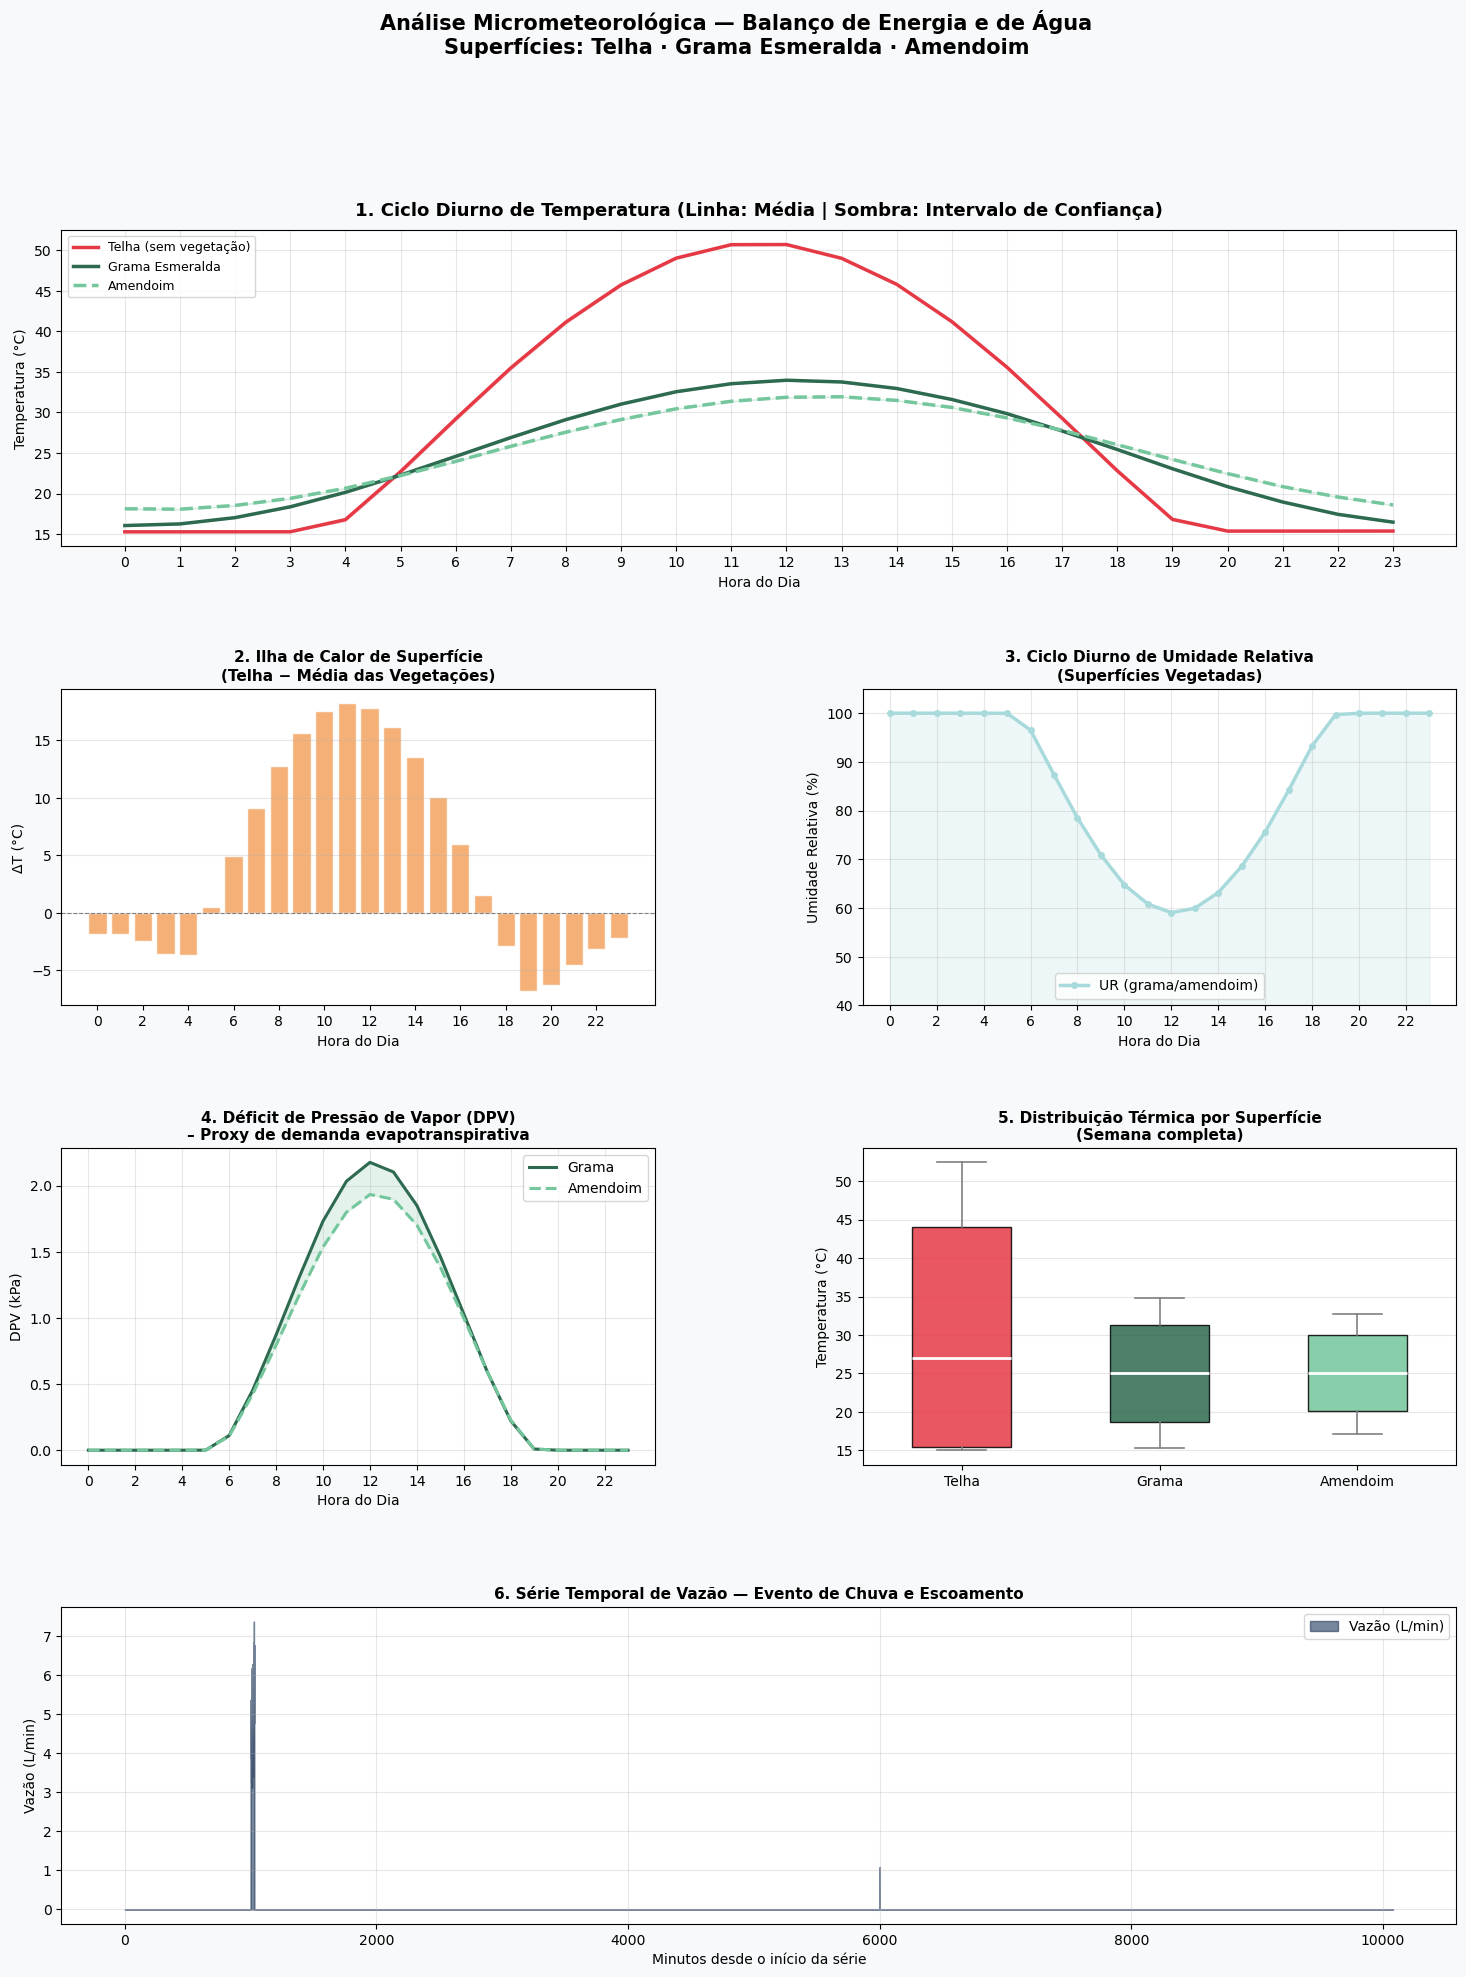

In [ ]:
"""
Análise Micrometeorológica — Balanço de Energia e de Água
Superfícies: Telha · Grama Esmeralda · Amendoim

Atualizado com Limpeza de Dados, Time Lag, Filtro Seco/Úmido e Bandas de Confiança.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ══════════════════════════════════════════════════════════════════════
# 1. CARREGAR, PREPARAR E LIMPAR OS DADOS (NOVO)
# ══════════════════════════════════════════════════════════════════════
df = pd.read_csv('dados_meteorologia_teste.csv', sep=';', decimal=',')
df['Data_Hora'] = pd.to_datetime(df['Data_Hora'])
df.set_index('Data_Hora', inplace=True)

# --- MELHORIA 1: Limpeza de Outliers (Blindagem do Sensor) ---
# Filtra valores fisicamente impossíveis para a região e interpola os buracos
colunas_temp = ['temp_telha', 'temp_grama', 'temp_amendoim']
for col in colunas_temp:
    df.loc[(df[col] < 15) | (df[col] > 75), col] = np.nan
df.interpolate(method='linear', inplace=True) # Preenche falhas suaves

# ══════════════════════════════════════════════════════════════════════
# 2. FEATURES DERIVADAS
# ══════════════════════════════════════════════════════════════════════

def pressao_saturacao(T):
    return 0.6108 * np.exp(17.27 * T / (T + 237.3))

df['dpv_grama']    = pressao_saturacao(df['temp_grama'])    * (1 - df['ur_grama'] / 100)
df['dpv_amendoim'] = pressao_saturacao(df['temp_amendoim']) * (1 - df['ur_grama'] / 100)

df['ilha_calor'] = df['temp_telha'] - (df['temp_grama'] + df['temp_amendoim']) / 2
df['hora'] = df.index.hour # Coluna auxiliar para o Seaborn

dia_medio = df.groupby('hora').mean(numeric_only=True)

# --- MELHORIA 3 & 4: Cálculos de Atraso Térmico e Dias Secos/Chuvosos ---
# Calcula o Time Lag médio (Atraso da vegetação em relação à telha)
lags_minutos = []
for dia, dados_dia in df.groupby(df.index.date):
    pico_telha = dados_dia['temp_telha'].idxmax()
    pico_amendoim = dados_dia['temp_amendoim'].idxmax()
    if pd.notna(pico_telha) and pd.notna(pico_amendoim):
        lag = (pico_amendoim - pico_telha).total_seconds() / 60
        lags_minutos.append(lag)
atraso_medio = np.mean(lags_minutos)

# Separa a média da Ilha de Calor por condição do tempo (Seco vs Chuva)
chuva_diaria = df['vazao'].resample('D').sum()
dias_chuvosos = chuva_diaria[chuva_diaria > 0].index.date
df['data_apenas'] = df.index.date
ilha_dias_secos = df[~df['data_apenas'].isin(dias_chuvosos)]['ilha_calor'].mean()
ilha_dias_chuva = df[df['data_apenas'].isin(dias_chuvosos)]['ilha_calor'].mean()

# ══════════════════════════════════════════════════════════════════════
# 3. ESTATÍSTICAS DE BALANÇO HÍDRICO E ENERGIA
# ══════════════════════════════════════════════════════════════════════
print("=" * 55)
print("ESTATÍSTICAS GERAIS")
print("=" * 55)
print(df[['temp_telha', 'temp_grama', 'temp_amendoim', 'ur_grama', 'vazao']].describe().round(2))

print("\n" + "=" * 55)
print("BALANÇO HÍDRICO — EVENTO DE CHUVA")
print("=" * 55)
print(f"Escoamento total acumulado : {df['vazao'].sum():.2f} L")
print(f"Pico de vazão              : {df['vazao'].max():.2f} L/min")
print(f"Minutos com escoamento > 0 : {(df['vazao'] > 0).sum()} min")

print("\n" + "=" * 55)
print("BALANÇO DE ENERGIA — ILHA DE CALOR E INÉRCIA")
print("=" * 55)
print(f"ΔT médio (Geral)         : {df['ilha_calor'].mean():.2f} °C")
print(f"ΔT médio (Dias Secos)    : {ilha_dias_secos:.2f} °C")
print(f"ΔT médio (Dias c/ Chuva) : {ilha_dias_chuva:.2f} °C")
print(f"ΔT máximo registrado     : {df['ilha_calor'].max():.2f} °C")
print(f"Atraso Térmico (Lag)     : {atraso_medio:.0f} minutos (Amendoim vs Telha)")

# ══════════════════════════════════════════════════════════════════════
# 4. FIGURAS
# ══════════════════════════════════════════════════════════════════════
CORES = {
    'telha':    '#E63946',
    'grama':    '#2D6A4F',
    'amendoim': '#74C69D',
    'ilha':     '#F4A261',
    'dpv':      '#457B9D',
    'vazao':    '#1D3557',
    'ur':       '#A8DADC',
}

horas = dia_medio.index

fig = plt.figure(figsize=(18, 22))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ─── Gráfico 1: Ciclo diurno com Bandas de Confiança (MELHORIA 2) ─────
ax1 = fig.add_subplot(gs[0, :])
# O Seaborn calcula automaticamente a variação (área sombreada) ao longo dos dias
sns.lineplot(data=df, x='hora', y='temp_telha', color=CORES['telha'], lw=2.5, label='Telha (sem vegetação)', ax=ax1)
sns.lineplot(data=df, x='hora', y='temp_grama', color=CORES['grama'], lw=2.5, label='Grama Esmeralda', ax=ax1)
sns.lineplot(data=df, x='hora', y='temp_amendoim', color=CORES['amendoim'], lw=2.5, linestyle='--', label='Amendoim', ax=ax1)

ax1.set_title('1. Ciclo Diurno de Temperatura (Linha: Média | Sombra: Intervalo de Confiança)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Hora do Dia')
ax1.set_ylabel('Temperatura (°C)')
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_facecolor('#FFFFFF')

# ─── Gráfico 2: Ilha de calor ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(horas, dia_medio['ilha_calor'], color=CORES['ilha'], alpha=0.85, edgecolor='white', width=0.8)
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_title('2. Ilha de Calor de Superfície\n(Telha − Média das Vegetações)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Hora do Dia')
ax2.set_ylabel('ΔT (°C)')
ax2.set_xticks(range(0, 24, 2))
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#FFFFFF')

# ─── Gráfico 3: Umidade Relativa ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(horas, dia_medio['ur_grama'], color=CORES['ur'], lw=2.5, marker='o', ms=4, label='UR (grama/amendoim)')
ax3.fill_between(horas, dia_medio['ur_grama'], alpha=0.2, color=CORES['ur'])
ax3.set_title('3. Ciclo Diurno de Umidade Relativa\n(Superfícies Vegetadas)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Hora do Dia')
ax3.set_ylabel('Umidade Relativa (%)')
ax3.set_xticks(range(0, 24, 2))
ax3.set_ylim(40, 105)
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_facecolor('#FFFFFF')

# ─── Gráfico 4: Déficit de Pressão de Vapor ───────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(horas, dia_medio['dpv_grama'],    color=CORES['grama'],    lw=2.2, label='Grama')
ax4.plot(horas, dia_medio['dpv_amendoim'], color=CORES['amendoim'], lw=2.2, ls='--', label='Amendoim')
ax4.fill_between(horas, dia_medio['dpv_grama'], dia_medio['dpv_amendoim'],
                 alpha=0.2, color=CORES['amendoim'])
ax4.set_title('4. Déficit de Pressão de Vapor (DPV)\n– Proxy de demanda evapotranspirativa', fontsize=11, fontweight='bold')
ax4.set_xlabel('Hora do Dia')
ax4.set_ylabel('DPV (kPa)')
ax4.set_xticks(range(0, 24, 2))
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_facecolor('#FFFFFF')

# ─── Gráfico 5: Boxplot ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
bp_data = [df['temp_telha'].dropna().values, df['temp_grama'].dropna().values, df['temp_amendoim'].dropna().values]
bp = ax5.boxplot(bp_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], [CORES['telha'], CORES['grama'], CORES['amendoim']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for whisker in bp['whiskers']:
    whisker.set(color='gray', lw=1.2)
for cap in bp['caps']:
    cap.set(color='gray', lw=1.2)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', markersize=2, alpha=0.4)
ax5.set_xticklabels(['Telha', 'Grama', 'Amendoim'])
ax5.set_title('5. Distribuição Térmica por Superfície\n(Semana completa)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Temperatura (°C)')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_facecolor('#FFFFFF')

# ─── Gráfico 6: Vazão ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
df_vazao = df['vazao'].copy()
ax6.fill_between(range(len(df_vazao)), df_vazao.values,
                 alpha=0.6, color=CORES['vazao'], label='Vazão (L/min)')
ax6.set_title('6. Série Temporal de Vazão — Evento de Chuva e Escoamento', fontsize=11, fontweight='bold')
ax6.set_xlabel('Minutos desde o início da série')
ax6.set_ylabel('Vazão (L/min)')
ax6.grid(True, alpha=0.3)
ax6.legend()
ax6.set_facecolor('#FFFFFF')

fig.suptitle('Análise Micrometeorológica — Balanço de Energia e de Água\nSuperfícies: Telha · Grama Esmeralda · Amendoim',
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('painel_meteorologia.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print("Painel salvo como 'painel_meteorologia.png'!")
plt.show()